In [312]:
#!pip install yfinance
#!pip install pandas_datareader

In [313]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader.data import DataReader
import yfinance as yf
from pandas_datareader import data as pdr

# yf.pdr_override()

In [314]:
from datetime import datetime

tech_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
end = datetime.now()
start = datetime(end.year-2, end.month, end.day)

In [315]:
for stock in tech_list:
    globals()[stock] = yf.download(stock, start, end)

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  globals()[stock] = yf.download(stock, start, end)
[*********************100%***********************]  1 of 1 completed
/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2406771750.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to Tr

In [316]:
AAPL.columns = AAPL.columns.droplevel(1)
GOOG.columns = GOOG.columns.droplevel(1)
MSFT.columns = MSFT.columns.droplevel(1)
AMZN.columns = AMZN.columns.droplevel(1)

In [317]:
AAPL

Price,Close,High,Low,Open,Volume
Date,,,,,
2023-09-25,174.372040,175.253406,172.460753,172.510271,46172700
2023-09-26,170.291992,173.500554,169.994899,173.124251,64588900
2023-09-27,168.776825,171.361509,167.410221,170.945584,66921800
2023-09-28,169.034317,170.361315,165.994089,167.697406,56294400
2023-09-29,169.549286,171.391245,168.687715,170.351427,51861100
...,...,...,...,...,...
2025-09-16,238.149994,241.220001,236.320007,237.179993,63421100
2025-09-17,238.990005,240.100006,237.729996,238.970001,46508000
2025-09-18,237.880005,241.199997,236.649994,239.970001,44249600


In [318]:
company_list = [AAPL, GOOG, MSFT, AMZN]
company_name = ['APPLE', 'GOOGLE', 'MICROSOFT', 'AMAZON']


In [319]:
for company, com_name in zip(company_list, company_name):
    company['company_name'] = com_name

In [320]:
df = pd.concat(company_list, axis=0)

In [321]:
df.tail()

Price,Close,High,Low,Open,Volume,company_name
Date,,,,,,
2025-09-16,234.050003,235.899994,232.229996,232.940002,38203900,AMAZON
2025-09-17,231.619995,234.300003,228.710007,233.770004,42815200,AMAZON
2025-09-18,231.229996,233.479996,228.789993,232.500000,37931700,AMAZON
2025-09-19,231.479996,234.160004,229.699997,232.369995,97943200,AMAZON
2025-09-22,227.630005,230.570007,227.509995,230.559998,45786800,AMAZON


In [322]:
AAPL.describe()

Price,Close,High,Low,Open,Volume
count,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,207.168377,209.084414,204.975746,206.901637,5.675060e+07
std,23.844716,24.003633,23.509315,23.788723,2.682338e+07
min,163.823563,165.213575,162.910124,164.171070,2.323470e+07
25%,187.658981,188.997386,185.734275,187.247848,4.238655e+07
50%,209.741959,212.212245,207.553404,209.776924,5.043100e+07
75%,226.936825,228.828212,224.685721,226.849220,6.241002e+07
max,258.103729,259.179926,256.718662,257.276679,3.186799e+08


In [323]:
AAPL.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 500 entries, 2023-09-25 to 2025-09-22
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         500 non-null    float64
 1   High          500 non-null    float64
 2   Low           500 non-null    float64
 3   Open          500 non-null    float64
 4   Volume        500 non-null    int64  
 5   company_name  500 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 27.3+ KB


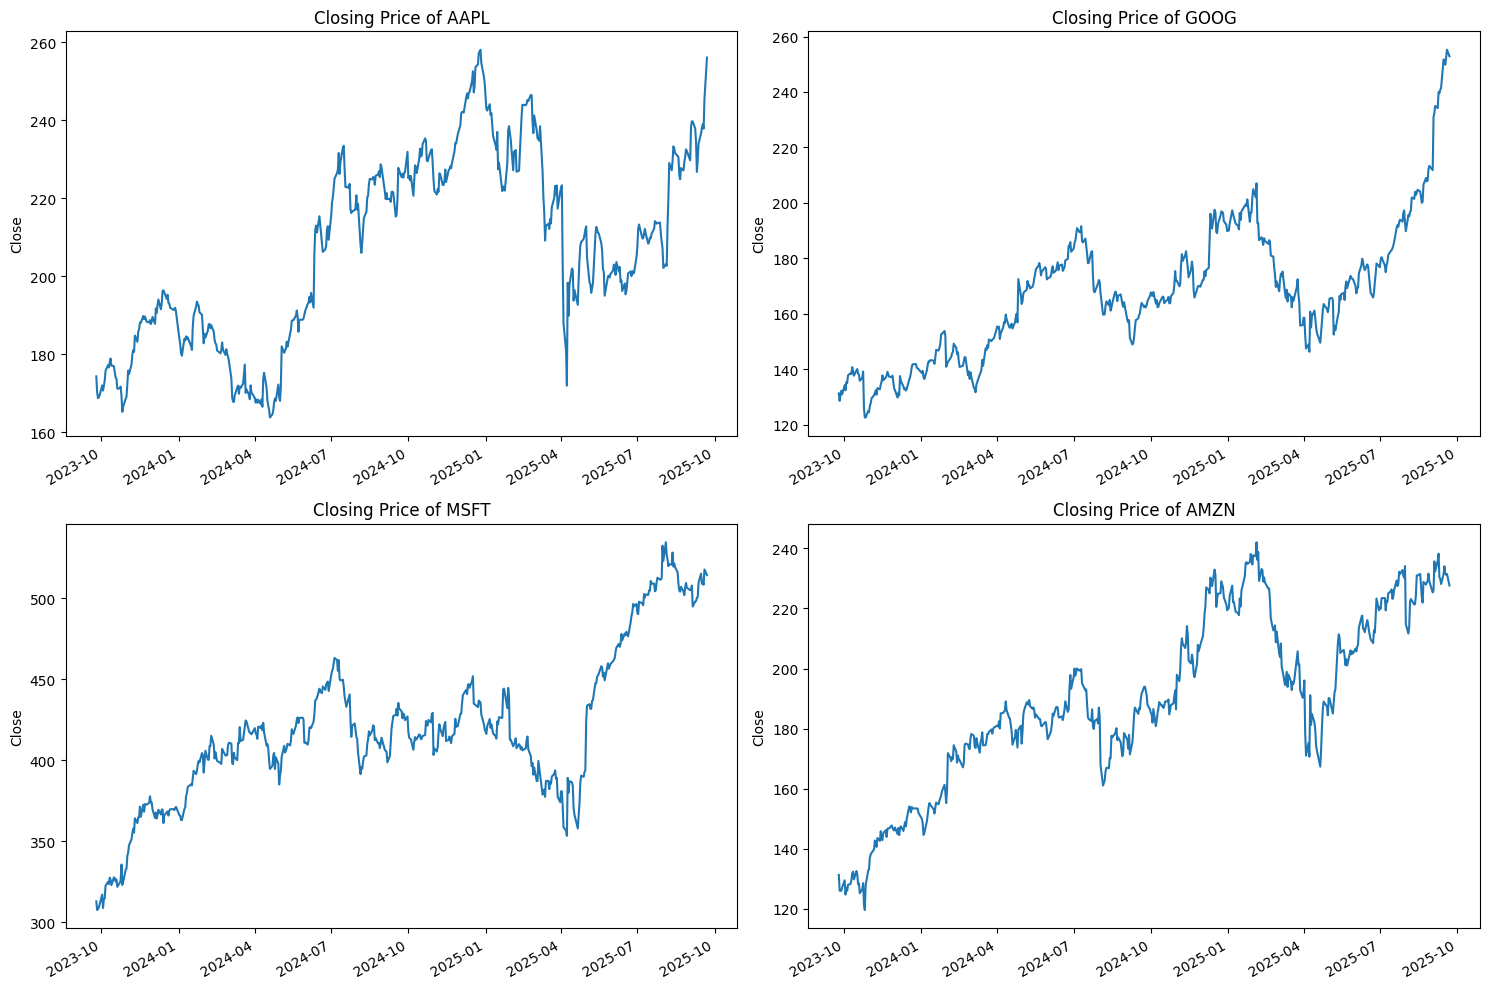

In [324]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Close'].plot()
    plt.ylabel('Close')
    plt.xlabel(None)
    plt.title(f'Closing Price of {tech_list[i-1]}')

plt.tight_layout()


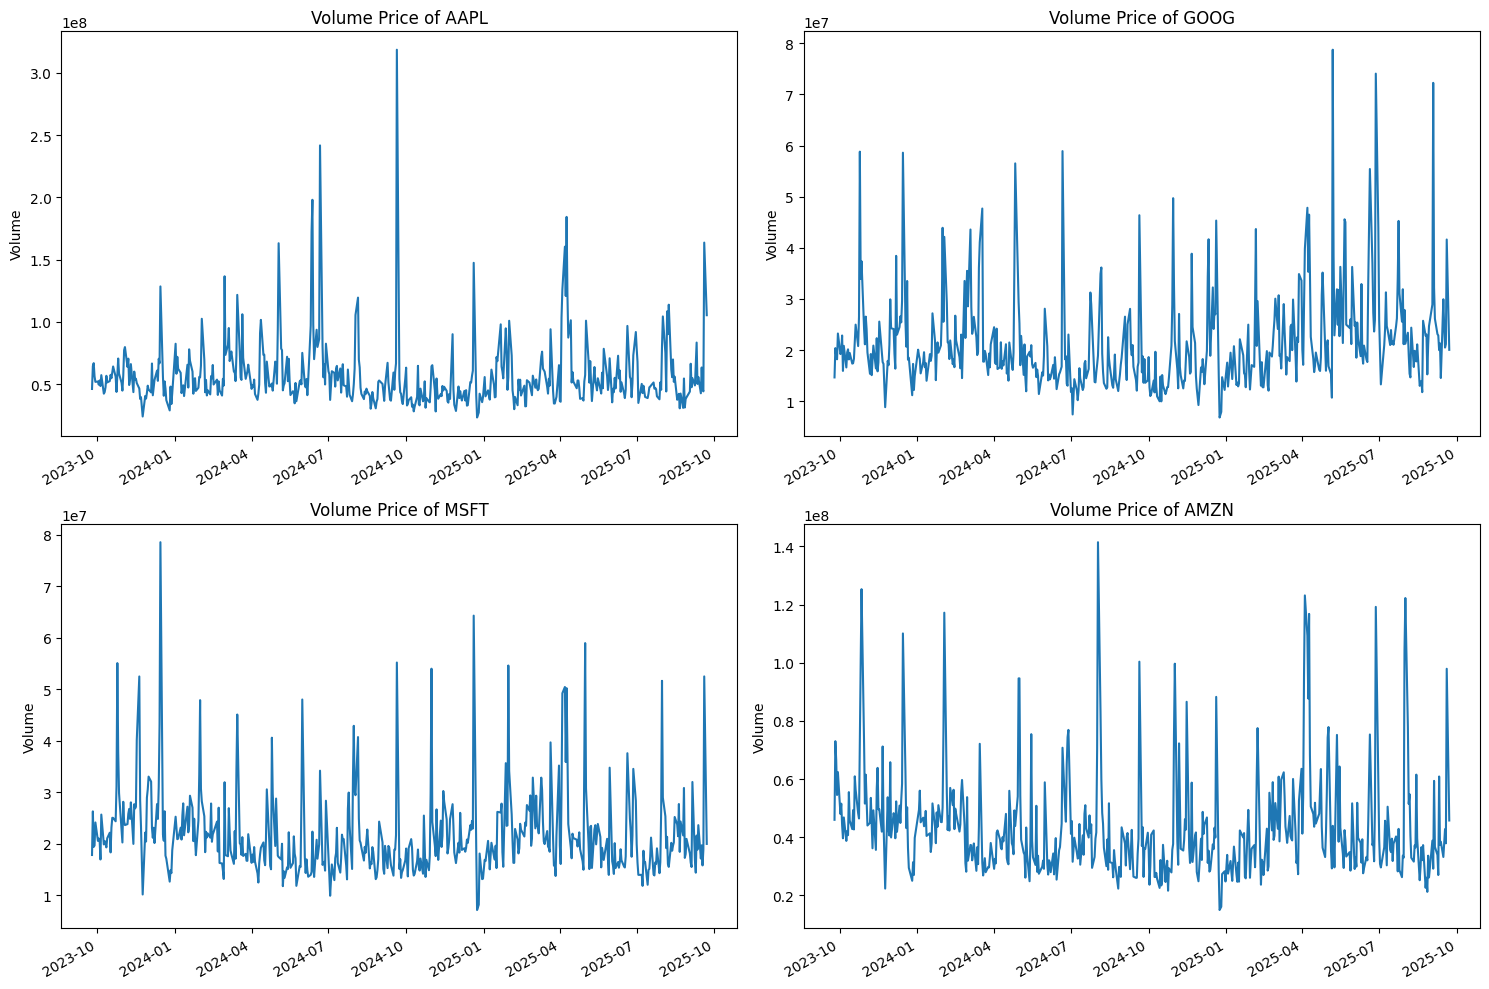

In [325]:
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Volume'].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f'Volume Price of {tech_list[i-1]}')

plt.tight_layout()

### Модель MA скользящее среднее

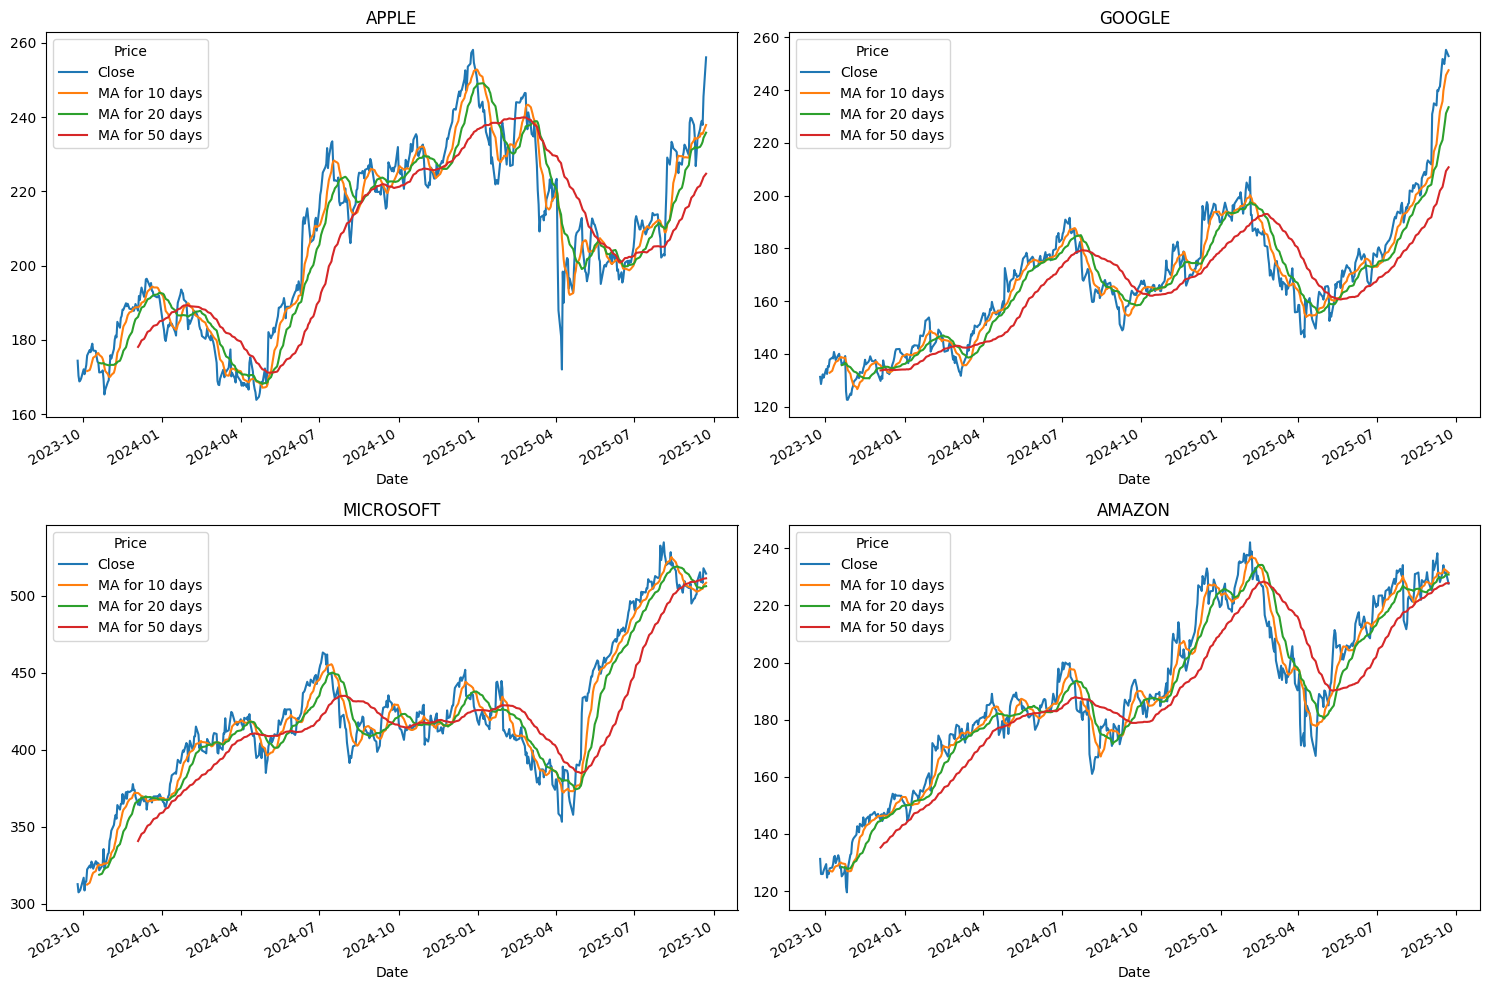

In [326]:
ma_day = [10, 20, 50]
for ma in ma_day:
    for company in company_list:
        column_name = f'MA for {ma} days'
        company[column_name] = company['Close'].rolling(ma).mean()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

GOOG[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

MSFT[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

AMZN[['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')

fig.tight_layout()

### Дневные изменения

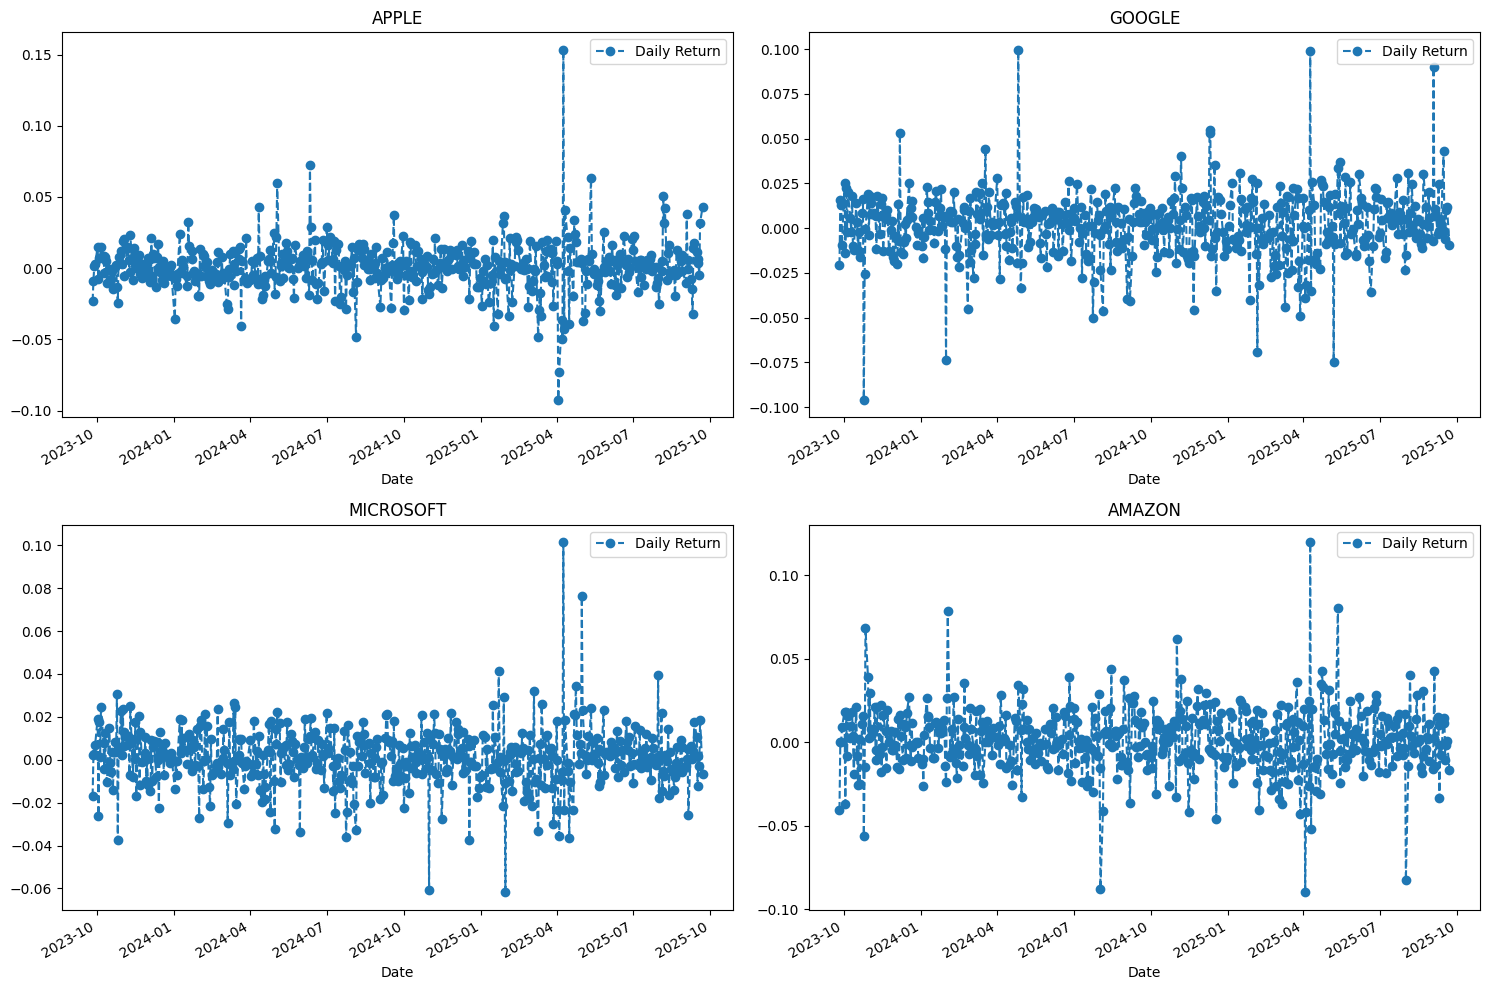

In [327]:
for company in company_list:
    company['Daily Return'] = company['Close'].pct_change()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)

AAPL['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle ='--', marker='o')
axes[0,0].set_title('APPLE')

GOOG['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle ='--', marker='o')
axes[0,1].set_title('GOOGLE')

MSFT['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle ='--', marker='o')
axes[1,0].set_title('MICROSOFT')

AMZN['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle ='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()

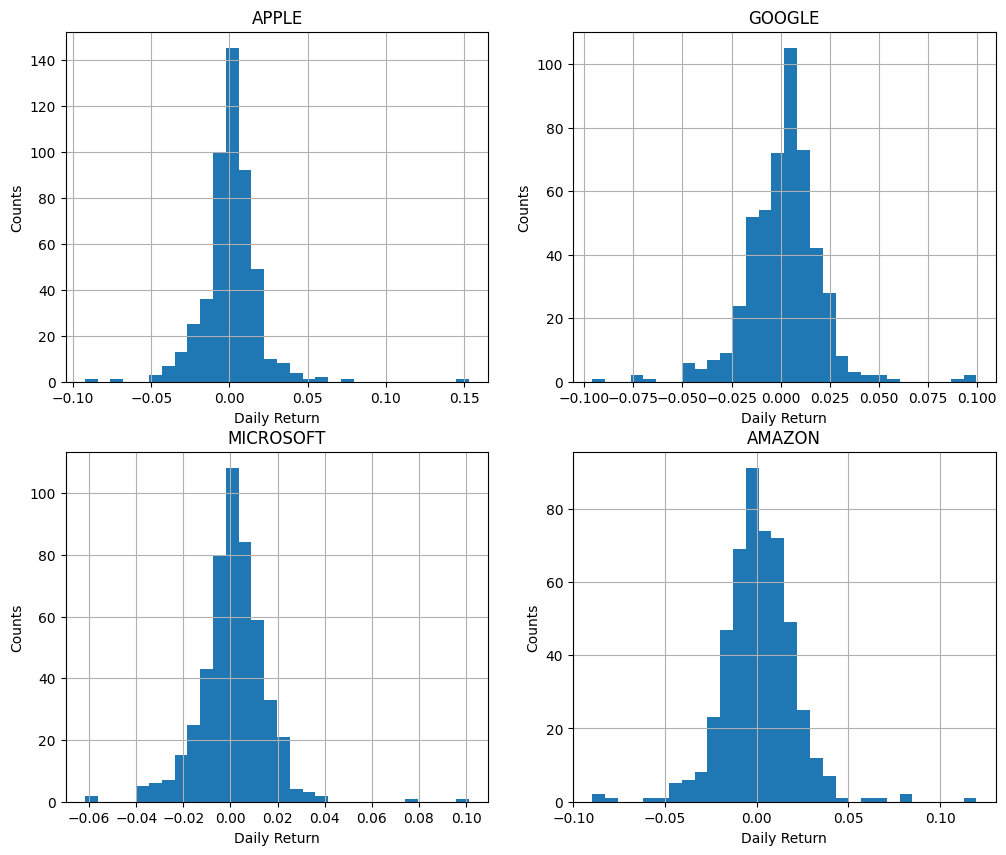

In [328]:
plt.figure(figsize=(12,10))
for i, company in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    company['Daily Return'].hist(bins=30)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{company_name[i-1]}')

fig.tight_layout()

In [329]:
closing_df = yf.download(tech_list, start=start, end=end)['Close']

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/2746958638.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  closing_df = yf.download(tech_list, start=start, end=end)['Close']
[*********************100%***********************]  4 of 4 completed


In [330]:
tech_rets = closing_df.pct_change()
tech_rets.head(10)

Ticker,AAPL,AMZN,GOOG,MSFT
Date,,,,
2023-09-25,NaN,NaN,NaN,NaN
2023-09-26,-0.023399,-0.040299,-0.020579,-0.017006
2023-09-27,-0.008897,0.000000,0.015527,0.002082
2023-09-28,0.001526,0.000000,0.012704,0.002717
2023-09-29,0.003047,0.009049,-0.009615,0.006727
2023-10-02,0.014836,0.018408,0.025180,0.019161
2023-10-03,-0.007770,-0.036614,-0.013835,-0.026134
2023-10-04,0.007309,0.018281,0.022281,0.017773
2023-10-05,0.007198,-0.008189,-0.002055,0.001254


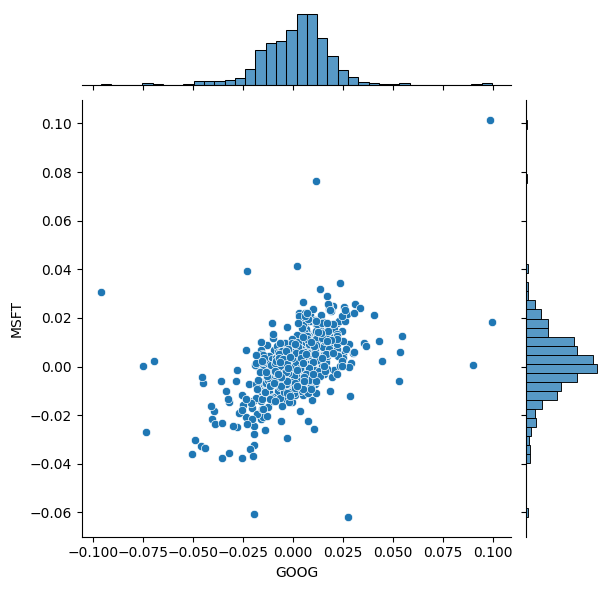

In [331]:
sns.jointplot(x='GOOG', y='MSFT', data=tech_rets, kind='scatter')
plt.show()

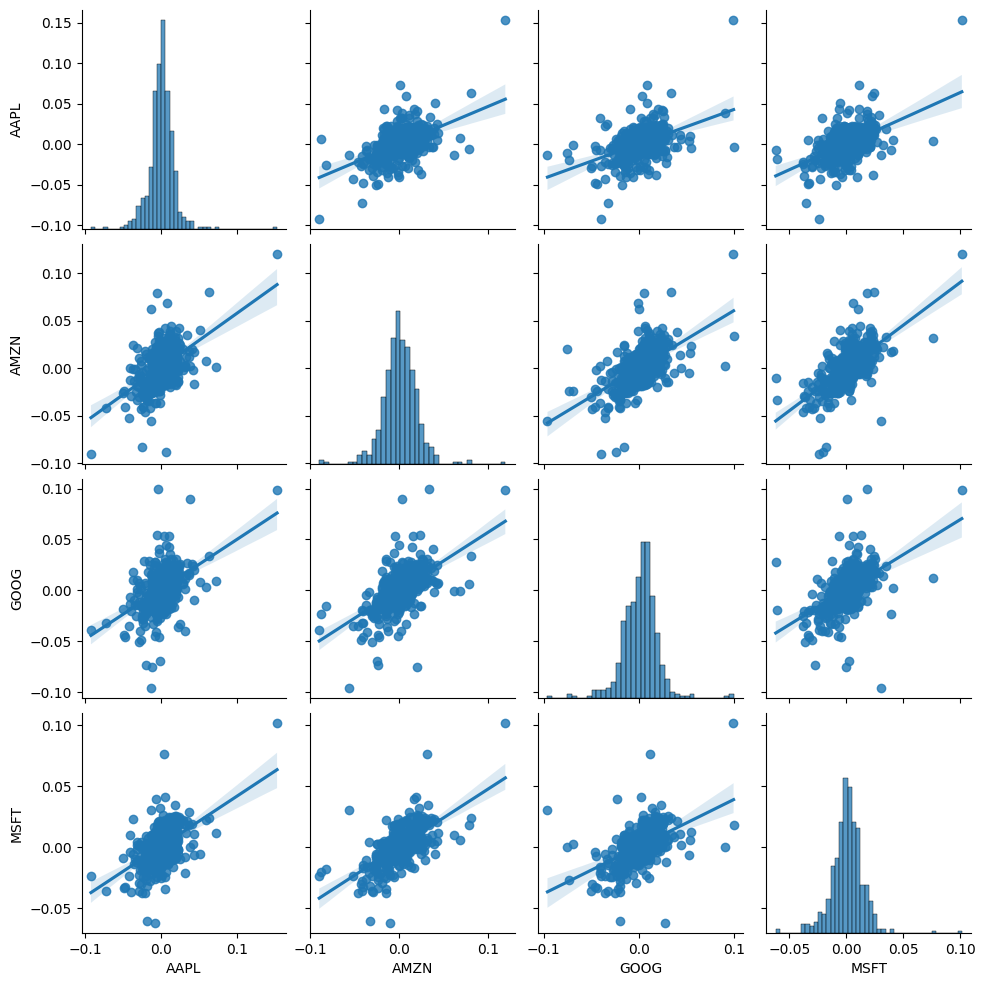

In [332]:
sns.pairplot(tech_rets, kind='reg')
plt.show()

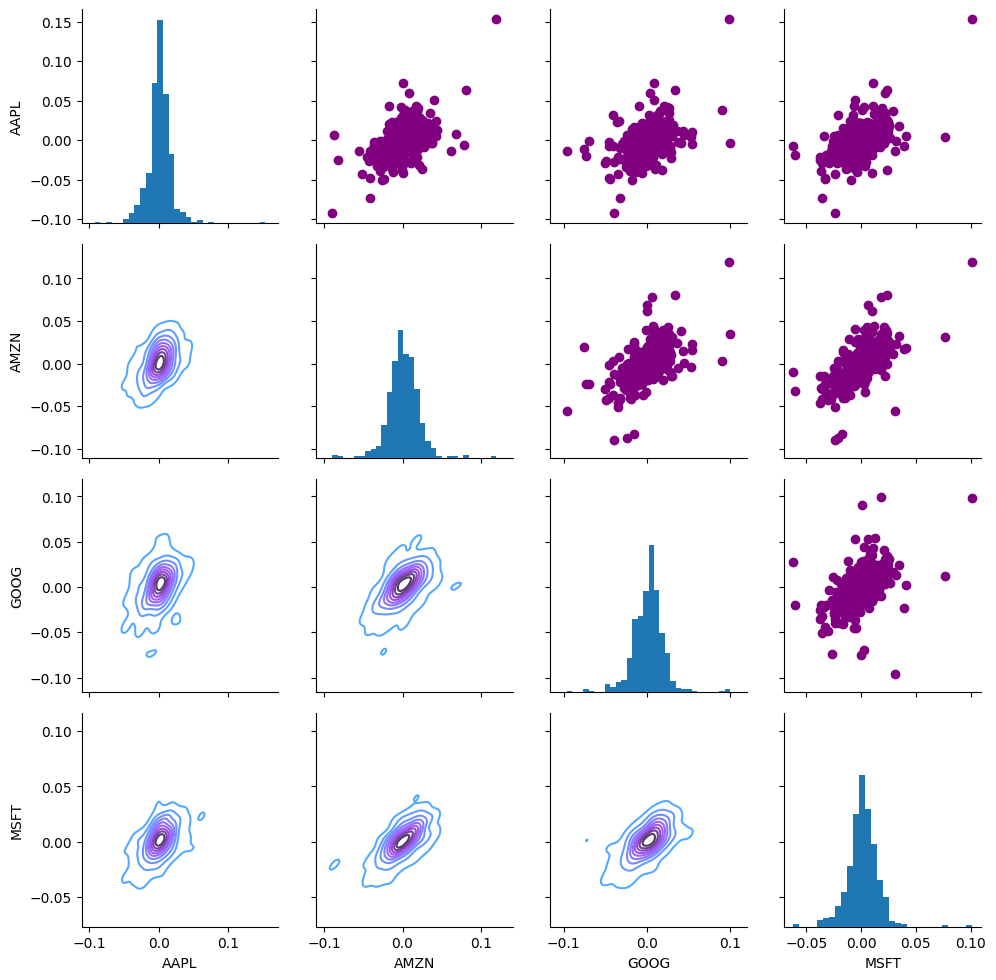

In [333]:
return_fig = sns.PairGrid(tech_rets.dropna())
return_fig.map_upper(plt.scatter, color='purple')
return_fig.map_lower(sns.kdeplot, cmap='cool_d')
return_fig.map_diag(plt.hist, bins=30)
plt.show()


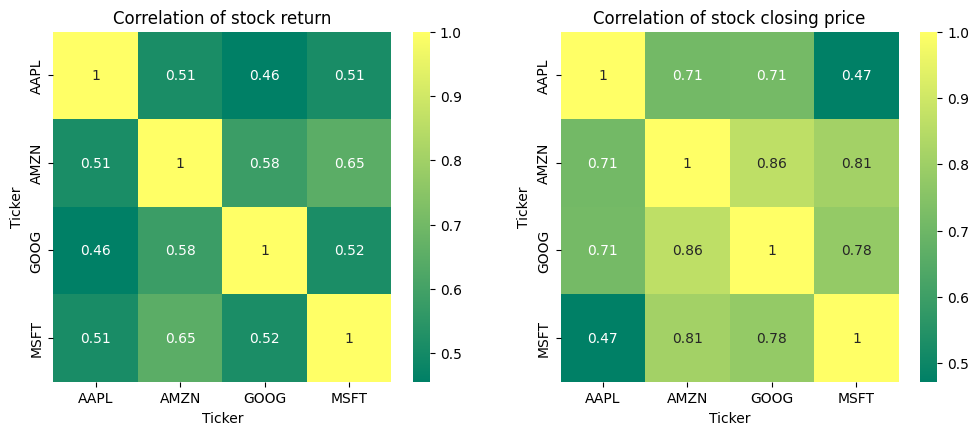

In [334]:
plt.figure(figsize=(12, 10))
plt.subplot(2,2,1)
sns.heatmap(tech_rets.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2,2,2)
sns.heatmap(closing_df.corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

fig.tight_layout()

In [335]:
df = yf.download('AAPL', start='2012-01-01', end=datetime.now())

/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/1392257192.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2012-01-01', end=datetime.now())
[*********************100%***********************]  1 of 1 completed


In [336]:
df

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2012-01-03,12.345171,12.383297,12.278227,12.290235,302220800
2012-01-04,12.411514,12.448740,12.286631,12.308245,260022000
2012-01-05,12.549309,12.564919,12.388400,12.456847,271269600
2012-01-06,12.680497,12.691004,12.585033,12.601544,318292800
2012-01-09,12.660382,12.841103,12.648974,12.773559,394024400
...,...,...,...,...,...
2025-09-16,238.149994,241.220001,236.320007,237.179993,63421100
2025-09-17,238.990005,240.100006,237.729996,238.970001,46508000


In [337]:
df.columns = df.columns.droplevel(1)

In [338]:
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2012-01-03,12.345171,12.383297,12.278227,12.290235,302220800
2012-01-04,12.411514,12.448740,12.286631,12.308245,260022000
2012-01-05,12.549309,12.564919,12.388400,12.456847,271269600
2012-01-06,12.680497,12.691004,12.585033,12.601544,318292800
2012-01-09,12.660382,12.841103,12.648974,12.773559,394024400
...,...,...,...,...,...
2025-09-16,238.149994,241.220001,236.320007,237.179993,63421100
2025-09-17,238.990005,240.100006,237.729996,238.970001,46508000
2025-09-18,237.880005,241.199997,236.649994,239.970001,44249600


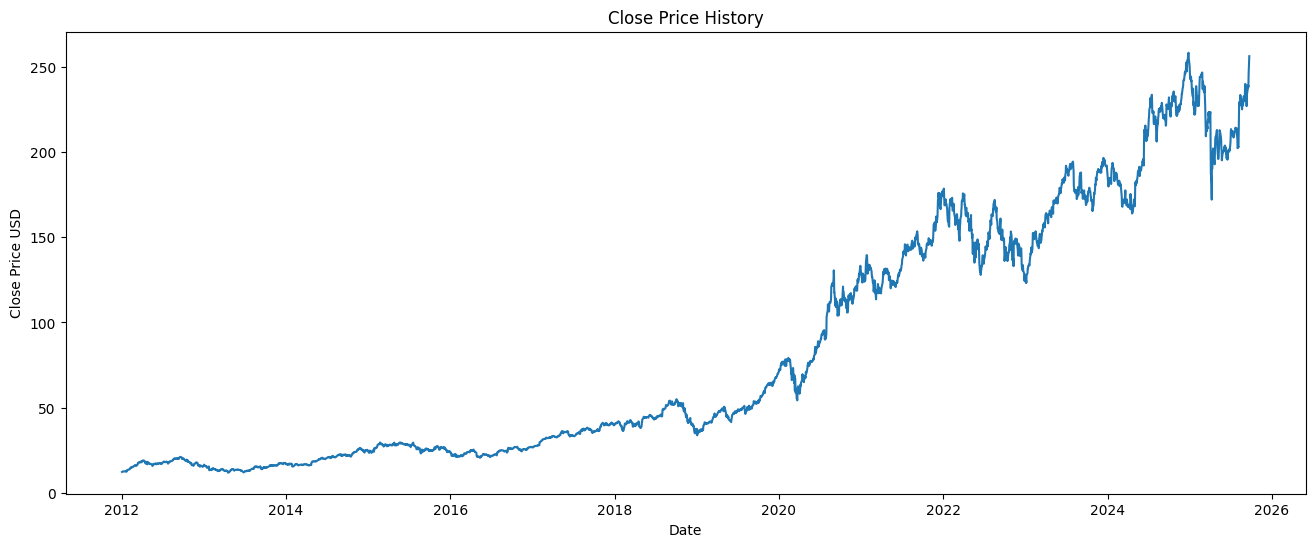

In [339]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.show()


In [340]:
data = df.filter(['Close'])
dataset = data.values
training_data_len = int(np.ceil(len(dataset)*0.95))
training_data_len

3278

In [341]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)
scaled_data

array([[0.00182109],
       [0.00209056],
       [0.00265023],
       ...,
       [0.91785883],
       [0.94880839],
       [0.99178032]], shape=(3450, 1))

In [342]:
train_data = scaled_data[0:training_data_len, :]
X_train = []
y_train = []
for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i == 60:
        print(X_train)
        print(y_train)

[array([0.00182109, 0.00209056, 0.00265023, 0.00318306, 0.00310136,
       0.00328548, 0.00320136, 0.0030599 , 0.00286726, 0.0034635 ,
       0.00400121, 0.00383539, 0.00292702, 0.00379393, 0.00294043,
       0.00614111, 0.00589358, 0.00621669, 0.00691535, 0.00733845,
       0.00730309, 0.00717263, 0.00772863, 0.0082517 , 0.0088443 ,
       0.00980144, 0.01181208, 0.01184256, 0.01296188, 0.01379833,
       0.01236077, 0.01291434, 0.01290337, 0.01445554, 0.01423485,
       0.01464329, 0.01537731, 0.01578581, 0.01696245, 0.01781959,
       0.01806713, 0.0181537 , 0.01668806, 0.01633448, 0.01638692,
       0.01776473, 0.01815246, 0.01898525, 0.0209483 , 0.0235674 ,
       0.02307725, 0.02307845, 0.02497202, 0.02556464, 0.02514274,
       0.02475744, 0.0243563 , 0.02568899, 0.02660346, 0.02698634])]
[np.float64(0.02604013115991983)]


In [343]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [344]:
X_train

array([[0.00182109, 0.00209056, 0.00265023, ..., 0.02568899, 0.02660346,
        0.02698634],
       [0.00209056, 0.00265023, 0.00318306, ..., 0.02660346, 0.02698634,
        0.02604013],
       [0.00265023, 0.00318306, 0.00310136, ..., 0.02698634, 0.02604013,
        0.02478304],
       ...,
       [0.88678136, 0.89709048, 0.88872187, ..., 0.94325756, 0.93196575,
        0.9339489 ],
       [0.89709048, 0.88872187, 0.89021765, ..., 0.93196575, 0.9339489 ,
        0.91027248],
       [0.88872187, 0.89021765, 0.90173969, ..., 0.9339489 , 0.91027248,
        0.90035665]], shape=(3218, 60))

In [345]:
y_train

array([0.02604013, 0.02478304, 0.02710947, ..., 0.91027248, 0.90035665,
       0.8958237 ], shape=(3218,))

In [346]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [347]:
X_train

array([[[0.00182109],
        [0.00209056],
        [0.00265023],
        ...,
        [0.02568899],
        [0.02660346],
        [0.02698634]],

       [[0.00209056],
        [0.00265023],
        [0.00318306],
        ...,
        [0.02660346],
        [0.02698634],
        [0.02604013]],

       [[0.00265023],
        [0.00318306],
        [0.00310136],
        ...,
        [0.02698634],
        [0.02604013],
        [0.02478304]],

       ...,

       [[0.88678136],
        [0.89709048],
        [0.88872187],
        ...,
        [0.94325756],
        [0.93196575],
        [0.9339489 ]],

       [[0.89709048],
        [0.88872187],
        [0.89021765],
        ...,
        [0.93196575],
        [0.9339489 ],
        [0.91027248]],

       [[0.88872187],
        [0.89021765],
        [0.90173969],
        ...,
        [0.9339489 ],
        [0.91027248],
        [0.90035665]]], shape=(3218, 60, 1))

In [348]:
# !pip install keras

In [349]:
# !pip install tensorflow

In [350]:
# !pip install tensorflow-macos tensorflow-metal

In [351]:
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.20.0


[]

In [352]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model.add(LSTM(32, return_sequences=False))
model.add(Dense(8))
model.add(Dense(1))


/Users/artemgolubnichiy/myJupyterNotebook/.conda/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [353]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(X_train, y_train, batch_size=1, epochs=3)

Epoch 1/3
3218/3218 ━━━━━━━━━━━━━━━━━━━━ 41s 12ms/step - loss: 9.4345e-04
Epoch 2/3
3218/3218 ━━━━━━━━━━━━━━━━━━━━ 36s 11ms/step - loss: 3.8917e-04
Epoch 3/3
3218/3218 ━━━━━━━━━━━━━━━━━━━━ 37s 11ms/step - loss: 2.5503e-04


In [354]:
test_data = scaled_data[training_data_len-60:, :]
X_test = []
y_test = dataset[training_data_len: , :]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

rmse = np.sqrt(np.mean(((predictions - y_test)**2)))
print(rmse)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
5.30252860337726


/var/folders/24/z61d72zx27z5ml8twybhwmm40000gn/T/ipykernel_96973/11834701.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


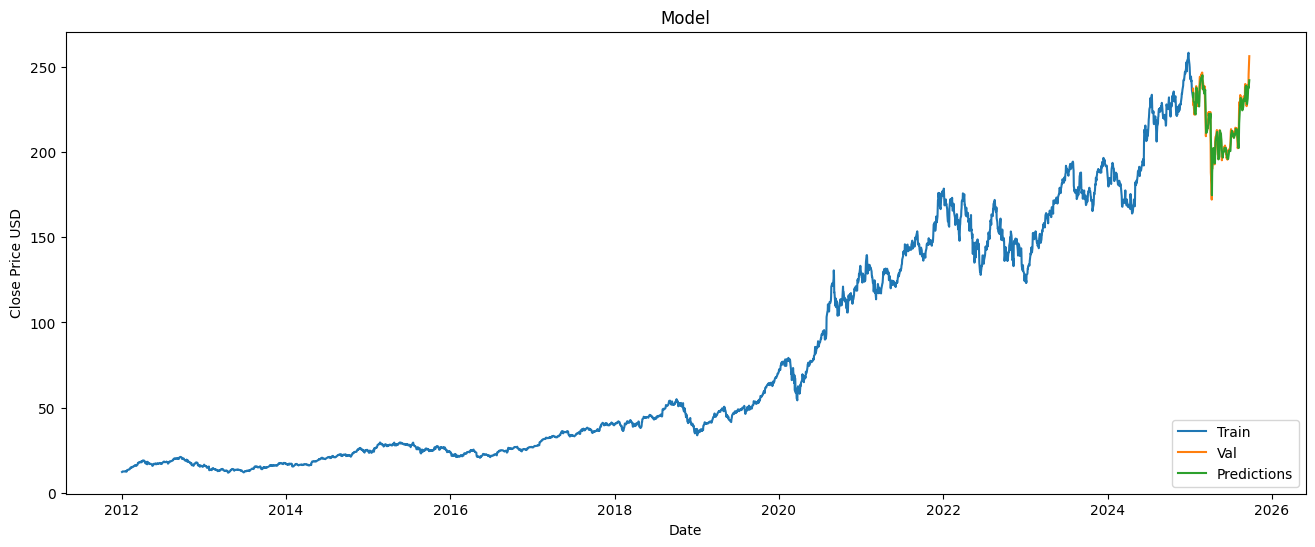

In [355]:
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions

plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price USD')
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()